### Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. 
These elements can be: Text, Images, Tables, etc.

In [3]:
from unstructured.partition.pdf import partition_pdf

output_dir = "./extracted_elements/"
file_path = "./Data/rag_paper.pdf"

chunks = partition_pdf(
    filename = file_path,
    infer_table_structure = True, # extract the tables
    strategy = "hi_res",
    extract_image_block_types = ["Image" , "Table"],
    extract_image_block_to_payload = True,
    max_characters=10000,                  
    combine_text_under_n_chars=2000,       
    new_after_n_chars=6000
)

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [4]:
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.FigureCaption'>",
 "<class 'unstructured.documents.elements.Footer'>",
 "<class 'unstructured.documents.elements.Formula'>",
 "<class 'unstructured.documents.elements.Header'>",
 "<class 'unstructured.documents.elements.Image'>",
 "<class 'unstructured.documents.elements.ListItem'>",
 "<class 'unstructured.documents.elements.NarrativeText'>",
 "<class 'unstructured.documents.elements.Table'>",
 "<class 'unstructured.documents.elements.Text'>",
 "<class 'unstructured.documents.elements.Title'>"}

In [8]:
len(chunks)

248

In [15]:
type(chunks[78])

unstructured.documents.elements.Footer

In [16]:
from unstructured.documents.elements import Image

sample = None 
for c in chunks:
    if isinstance(c , Image):
        sample = c 
        break

sample

In [22]:
import io
import base64
from PIL import Image

# 1. Get the base64 string from metadata
image_base64 = sample.metadata.image_base64

if image_base64:
    # 2. Decode the base64 string into bytes
    image_data = base64.b64decode(image_base64)
    
    # 3. Create a byte stream (buffer) from those bytes
    image_buffer = io.BytesIO(image_data)
    
    # 4. Open the image from the buffer
    img = Image.open(image_buffer)
    
    # 5. Display the image
    img.show()
else:
    print("No image data found in metadata. Ensure you used strategy='hi_res'.")

In [27]:
# separate tables
tables = []
texts = []
images_base64 = []

for chunk in chunks:
    # Check for Tables
    if "Table" in str(type(chunk)):
        tables.append(chunk)
    
    # Check for Text/Composite elements
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)
        
    # Check for Images and extract the base64 string
    elif "Image" in str(type(chunk)):
        if chunk.metadata.image_base64:
            images_base64.append(chunk.metadata.image_base64)

In [28]:
len(tables) , len(texts) , len(images_base64)

(5, 0, 4)

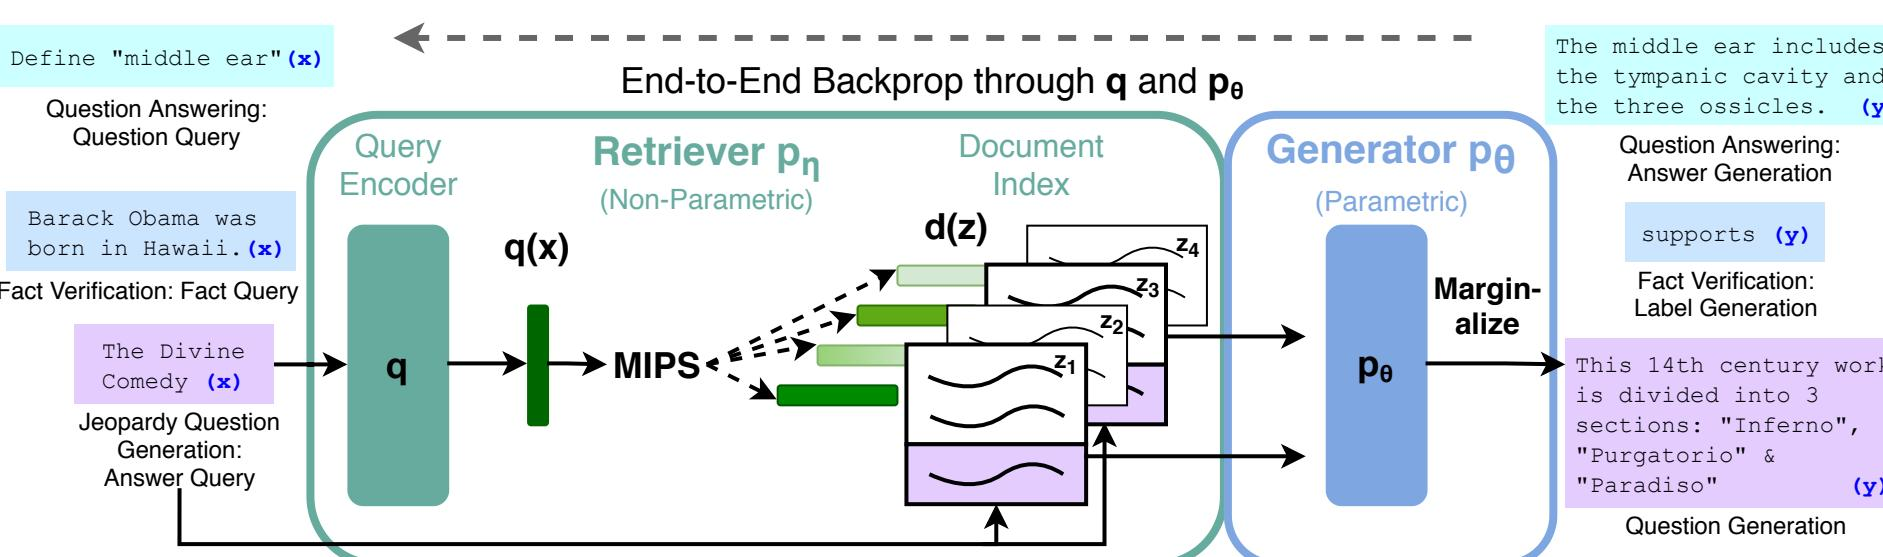

In [29]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images_base64[0])